<a href="https://colab.research.google.com/github/nurafnilussy-stack/UTS-Pengolahan-Citra-Digital/blob/main/UTS_PENGOLAHAN_CITRA_DIGITAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload citra grayscale (.jpg atau .png):


Saving singa.webp to singa (1).webp
Citra berhasil dibaca: singa (1).webp
Dimensi: (296, 474)


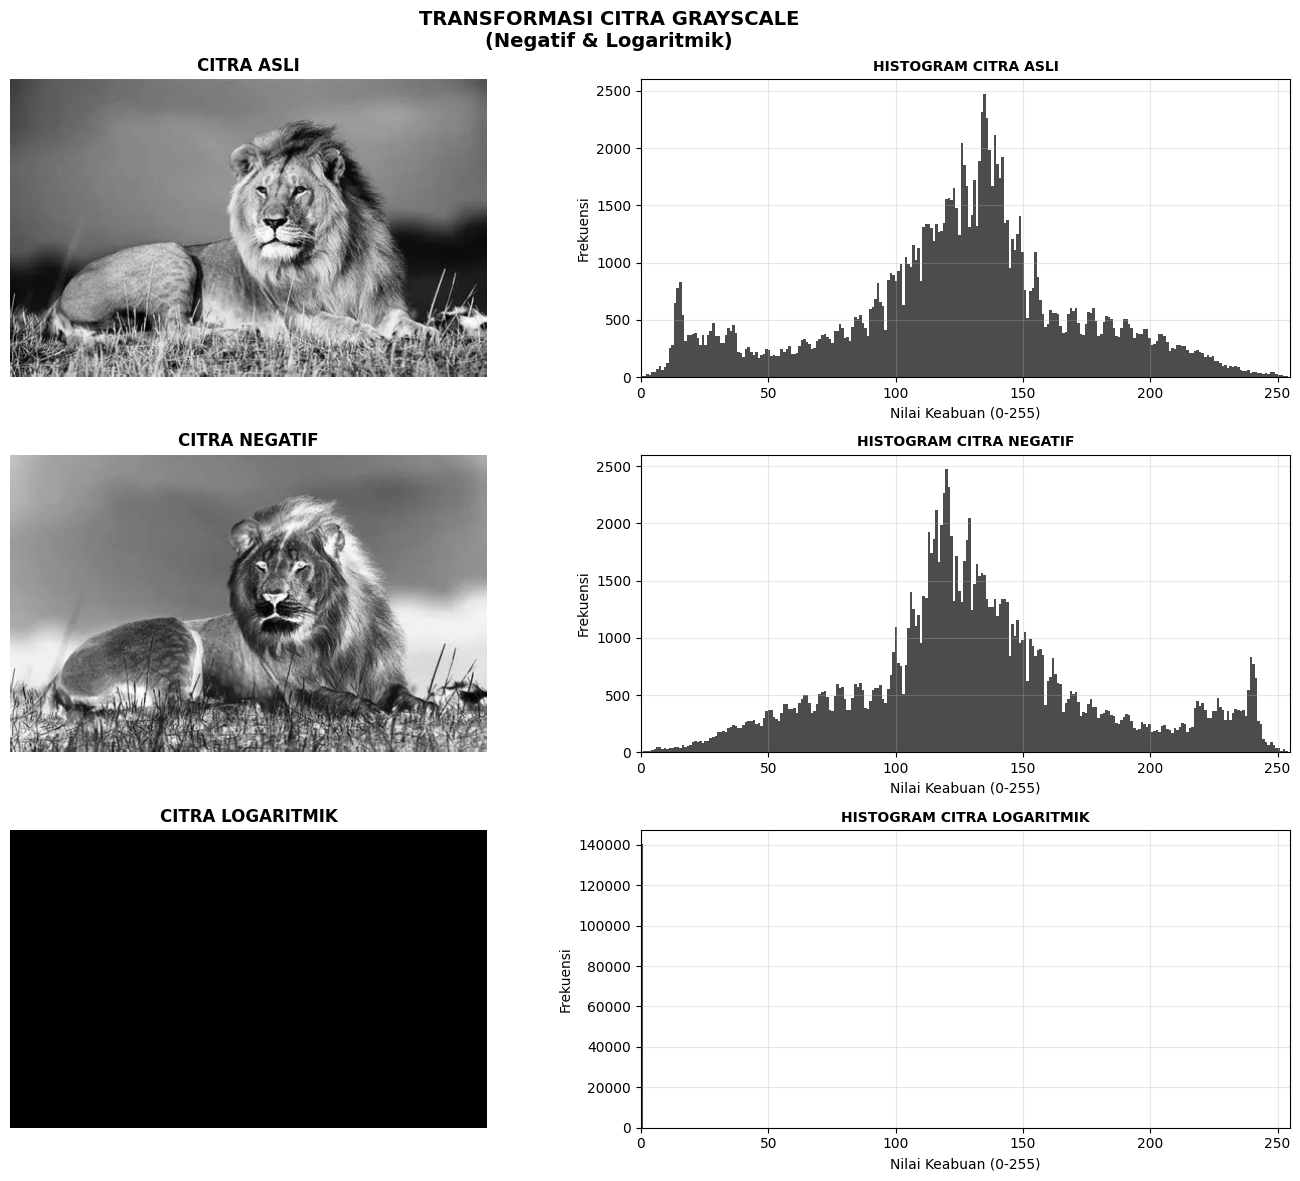

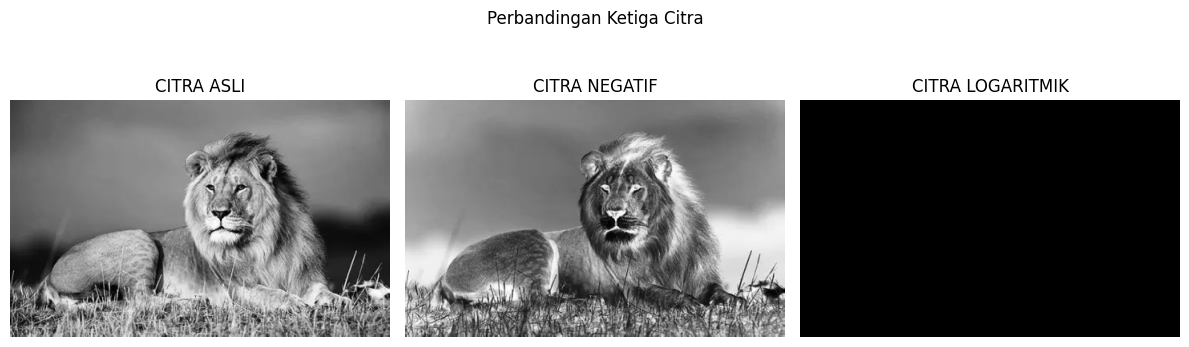


=== STATISTIK NILAI KEABUAN ===
Citra                Min      Max      Mean      
----------------------------------------------
CITRA ASLI           0        255      123.85    
CITRA NEGATIF        0        255      131.15    
CITRA LOGARITMIK     0        0        0.00      


In [ ]:
# -*- coding: utf-8 -*-
"""
UTS PENGOLAHAN CITRA DIGITAL - SOAL NO.1
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. UPLOAD DAN BACA CITRA GRAYSCALE
print("Upload citra grayscale (.jpg atau .png):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca sebagai grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
print(f"Citra berhasil dibaca: {filename}")
print(f"Dimensi: {img.shape}")

# 2. TRANSFORMASI NEGATIF
# Rumus: G = 255 - F
img_neg = 255 - img

# 3. TRANSFORMASI LOGARITMIK
# Rumus: G = c * log(1 + F)
# c = 255 / log(1 + max(F))
max_f = np.max(img)
c = 255 / np.log(1 + max_f)
img_log = c * np.log(1 + img.astype(np.float32))
img_log = np.clip(img_log, 0, 255)
img_log = np.uint8(img_log)

# 4. TAMPILKAN KEEMPAT GAMBAR + HISTOGRAM MASING-MASING
# Susunan: 3 baris x 2 kolom (kiri: citra, kanan: histogram)

plt.figure(figsize=(14, 12))

# Data
judul_citra = ['CITRA ASLI', 'CITRA NEGATIF', 'CITRA LOGARITMIK']
citra = [img, img_neg, img_log]

for i in range(3):
    # Kolom kiri: Citra
    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(citra[i], cmap='gray', vmin=0, vmax=255)
    plt.title(judul_citra[i], fontsize=12, fontweight='bold')
    plt.axis('off')

    # Kolom kanan: Histogram dari citra tersebut
    plt.subplot(3, 2, 2*i + 2)
    plt.hist(citra[i].ravel(), bins=256, range=(0, 255), color='black', alpha=0.7)
    plt.title(f'HISTOGRAM {judul_citra[i]}', fontsize=10, fontweight='bold')
    plt.xlabel('Nilai Keabuan (0-255)')
    plt.ylabel('Frekuensi')
    plt.xlim(0, 255)
    plt.grid(True, alpha=0.3)

plt.suptitle('TRANSFORMASI CITRA GRAYSCALE\n(Negatif & Logaritmik)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tampilkan juga ringkasan 3 citra dalam satu baris (opsional)
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(citra[i], cmap='gray', vmin=0, vmax=255)
    plt.title(judul_citra[i])
    plt.axis('off')
plt.suptitle('Perbandingan Ketiga Citra')
plt.tight_layout()
plt.show()

# Cetak nilai statistik
print("\n=== STATISTIK NILAI KEABUAN ===")
print(f"{'Citra':<20} {'Min':<8} {'Max':<8} {'Mean':<10}")
print("-"*46)
for nama, c in zip(judul_citra, citra):
    print(f"{nama:<20} {np.min(c):<8} {np.max(c):<8} {np.mean(c):<10.2f}")

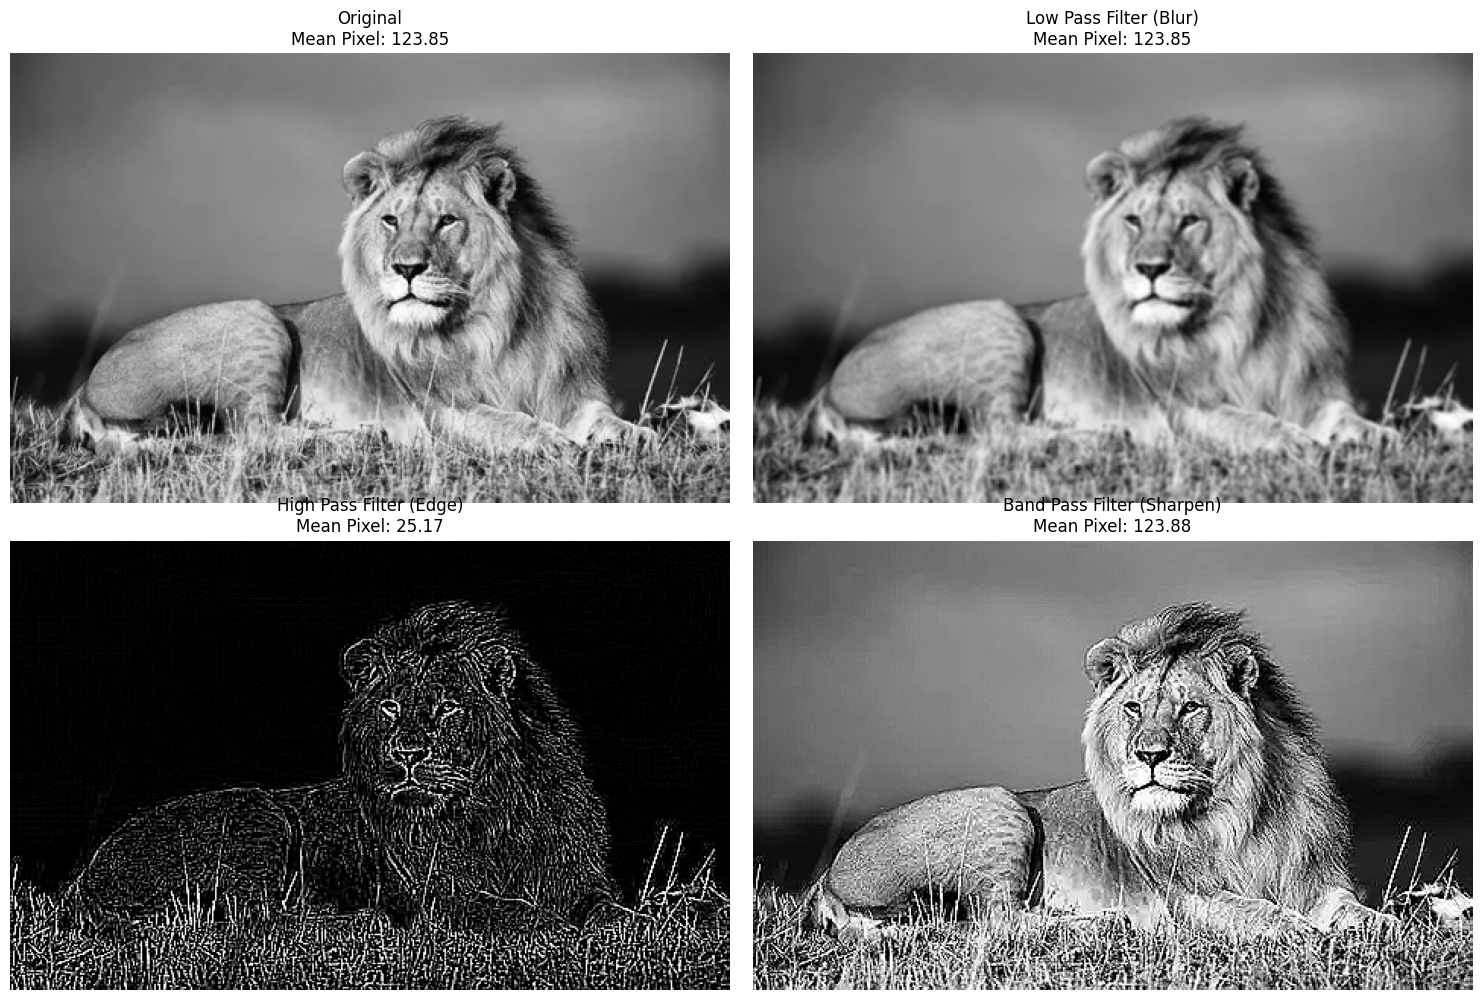

✅ Selesai! Gunakan nilai 'Mean Pixel' di atas untuk melengkapi analisa kamu.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. SETTING NAMA FILE ---
# Pastikan nama di bawah ini SAMA PERSIS dengan file yang kamu upload di Colab
nama_file = 'singa.webp'

if not os.path.exists(nama_file):
    print(f"❌ ERROR: File '{nama_file}' tidak ditemukan di folder Colab!")
    print("Silahkan klik icon folder di kiri, lalu upload file gambar kamu.")
else:
    # Membaca gambar (Grayscale)
    img = cv2.imread(nama_file, 0)

    # --- 2. DEFINISI KERNEL (Sesuai Soal) ---

    # Low Pass Filter (LPF) - Perata-rataan
    kernel_lpf = np.array([[1, 1, 1],
                           [1, 1, 1],
                           [1, 1, 1]]) / 9.0

    # High Pass Filter (HPF) - Deteksi Tepi
    kernel_hpf = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]])

    # Band Pass Filter (BPF) - Sharpening (Penajaman)
    kernel_bpf = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

    # --- 3. PROSES KONVOLUSI ---
    res_lpf = cv2.filter2D(img, -1, kernel_lpf)
    res_hpf = cv2.filter2D(img, -1, kernel_hpf)
    res_bpf = cv2.filter2D(img, -1, kernel_bpf)

    # --- 4. TAMPILKAN HASIL ---
    images = [img, res_lpf, res_hpf, res_bpf]
    titles = ['Original', 'Low Pass Filter (Blur)', 'High Pass Filter (Edge)', 'Band Pass Filter (Sharpen)']

    plt.figure(figsize=(15, 10))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"{titles[i]}\nMean Pixel: {np.mean(images[i]):.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("✅ Selesai! Gunakan nilai 'Mean Pixel' di atas untuk melengkapi analisa kamu.")